In [1]:
%matplotlib widget

from stellar_explorer import StellarExplorer
from stellar_explorer import ScatterDataset


In [2]:
DFP      = pd.read_csv("sample_data/demo_dataframe.csv")
DFP_hads = DFP[DFP['HADS']==1]

/Users/prasadmani/Downloads/scatter-explorer/stellar_explorer/explorer.py:118: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  artist = self.ax_scatter.scatter(


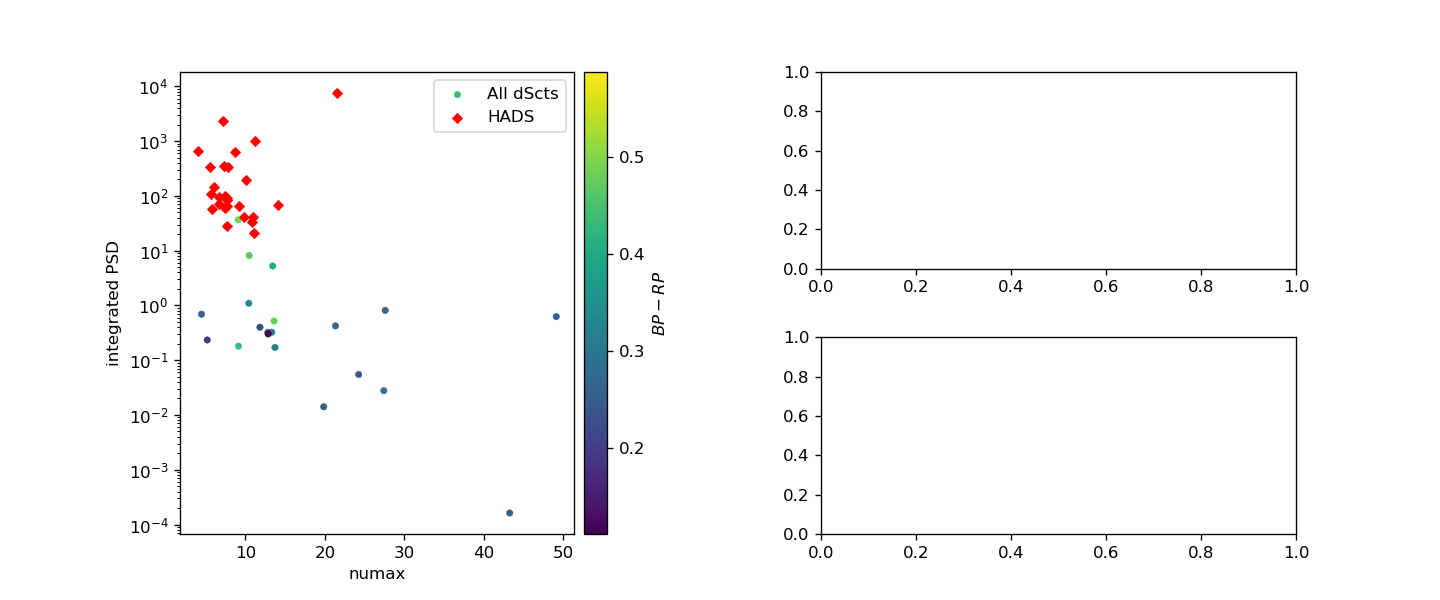

In [4]:
explorer = StellarExplorer(
    catalog_df        = DFP,
    lightcurve_dir    = "sample_data/LK",
    powerspectrum_dir = "sample_data/PS",
)

dataset1 = ScatterDataset(
    x     = DFP["centroid_power_above_5med_fb_shift"].values,
    y     = DFP["new_PSD"].values,
    ids   = DFP["tess"].values,
    color = DFP.bp_rp.values,
    cmap  = "viridis",
    show_colorbar  = True,
    colorbar_label = r"$BP - RP$",
    label          = "All dScts",
    picker         = 15
)

dataset2 = ScatterDataset(
    x    = DFP_hads["centroid_power_above_5med_fb_shift"].values,
    y    = DFP_hads["new_PSD"].values,
    ids  = DFP_hads["tess"].values,
    label  = "HADS",
    color  = 'red',
    marker = 'D', 
    size   = 20
)

explorer.show(
    datasets = [dataset1, dataset2],
    xlabel   = "numax",
    ylabel   = "integrated PSD", 
    yscale   = 'log', 
#     ylim     = (1.2*DFP.M_mag.max(), 1.5*DFP.M_mag.min())
)